In [15]:

# --- User configuration ---
mp_id = "mp-755769"                   # Example: silicon
mp_api_key = "gWPgvIQ1eNPzzdAMsAkelqNCh78VMRkL"                 # Or paste your key string; None => read from env MP_API_KEY

field_model_path = "MACEField-omat-dielectric.model"     # MACEField model path
hessian_model_path = "mace-mh-0.model" # Plain MACE model for Hessian 

field_model_head = "mp-dielectric"             # e.g. "pt_head" or "Default"
hessian_model_head = "omat_pbe"

electric_field = [0.0, 0.0, 0.0]   # V/Å
device = "cuda"                     # "cpu" or "cuda"

save_prefix = None                 # e.g. "out"
print_principal = True


## 1) Imports

In [16]:

from __future__ import annotations
import os
import numpy as np

# Materials Project API
from mp_api.client import MPRester
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor

# ASE
from ase import Atoms

# MACE calculator (direct import as requested)
from mace.calculators import MACECalculator

# Optional 3D widget
try:
    import nglview as nv
    HAS_NGL = True
except Exception:
    HAS_NGL = False

# Constants (SI)
EPS0 = 8.8541878128e-12     # F/m
E_CHG = 1.602176634e-19     # C
EV    = 1.602176634e-19     # J
ANG   = 1e-10               # m

# Conversions
E_PER_VA_to_F_PER_M   = E_CHG / ANG        # 1 e/(V Å) -> F/m
EV_PER_A2_to_J_PER_M2 = EV / (ANG**2)      # 1 eV/Å^2  -> J/m^2


## 2) Load structure by mp-id

In [17]:

# Resolve API key
mp_key = mp_api_key if mp_api_key is not None else os.getenv("MP_API_KEY")
if not mp_key:
    raise RuntimeError("No MP API key found. Set mp_api_key above or export MP_API_KEY in your environment.")

with MPRester(mp_key) as mpr:
    doc = mpr.materials.summary.search(material_ids=[mp_id], fields=["structure", "material_id"])
    if not doc:
        raise RuntimeError(f"mp-id {mp_id} not found")
    structure: Structure = doc[0].structure

# Convert to ASE Atoms
atoms: Atoms = AseAtomsAdaptor.get_atoms(structure)
print(f"Loaded {mp_id}: {len(atoms)} atoms, volume = {atoms.get_volume():.6f} Å^3, formula = {atoms.get_chemical_formula()}")


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Loaded mp-755769: 12 atoms, volume = 178.349099 Å^3, formula = O8Zr4


## 3) Visualize structure

In [18]:

if HAS_NGL:
    v = nv.show_pymatgen(structure)  # interactive viewer with cell
    v.add_unitcell()
    display(v)
else:
    # Fallback textual summary
    print("nglview not available. Install with `pip install nglview`.")
    print(structure)


NGLWidget()

## 4) Helper math: pseudoinverse, assembly, dielectric and phonon decomposition

In [19]:

def symmetric_pseudoinverse(C_SI: np.ndarray, tol: float = 1e-10) -> np.ndarray:
    """Symmetric pseudoinverse via eigendecomposition; removes acoustic modes."""
    C = 0.5 * (C_SI + C_SI.T)
    w, V = np.linalg.eigh(C)
    wmax = np.max(np.abs(w)) if w.size else 0.0
    eps = tol * (wmax if wmax > 0 else 1.0)
    w_inv = np.where(w > eps, 1.0 / w, 0.0)
    C_pinv = (V * w_inv) @ V.T
    return 0.5 * (C_pinv + C_pinv.T)


def assemble_Z(becs_e: np.ndarray) -> np.ndarray:
    """
    Arrange Z* into (3N, 3) with row order (atom0 x,y,z, atom1 x,y,z, ...), columns = field α.
    Input becs_e: (N, 3, 3) with indices (α, γ).
    """
    N = becs_e.shape[0]
    Z = np.zeros((3*N, 3), dtype=float)
    for k in range(N):
        Z[3*k+0, :] = becs_e[k][:, 0]
        Z[3*k+1, :] = becs_e[k][:, 1]
        Z[3*k+2, :] = becs_e[k][:, 2]
    return Z


def dielectric_from(alpha_chi: np.ndarray,
                    becs_e: np.ndarray,
                    hessian_eV_per_A2: np.ndarray,
                    volume_A3: float):
    """
    Return (eps_inf, eps_ion, eps_static).

    Parameters
    ----------
    alpha_chi : (3,3) ndarray
        Clamped-ion electric susceptibility χ (dimensionless), as returned by the model.
    becs_e : (N,3,3) ndarray
        Born effective charges in units of e, indexed (α, γ).
    hessian_eV_per_A2 : (3N,3N) ndarray
        Γ-point Cartesian Hessian in eV/Å² (coerced to 2D if needed before calling).
    volume_A3 : float
        Cell volume in Å³.
    """
    # ε∞ = I + χ  (χ is already dimensionless)
    eps_inf = np.eye(3) + alpha_chi * 4.0 * np.pi

    # Z* -> Coulomb, C -> J/m^2, Ω -> m^3
    Z_C = assemble_Z(becs_e * E_CHG)
    C_SI = hessian_eV_per_A2 * EV_PER_A2_to_J_PER_M2
    Omega = volume_A3 * (ANG**3)

    # Ionic susceptibility χ_ion = (Z^T C^+ Z) / (ε0 Ω)
    C_pinv = symmetric_pseudoinverse(C_SI, tol=1e-10)
    chi_ion = (Z_C.T @ C_pinv @ Z_C) / (EPS0 * Omega)

    # Symmetrize
    eps_inf  = 0.5 * (eps_inf + eps_inf.T)
    eps_ion  = 0.5 * (chi_ion + chi_ion.T)
    eps_static = 0.5 * (eps_inf + eps_ion + (eps_inf + eps_ion).T)
    return eps_inf, eps_ion, eps_static


def phonon_mode_decomposition(becs_e: np.ndarray,
                              hessian_eV_per_A2: np.ndarray,
                              masses_amu: np.ndarray,
                              volume_A3: float,
                              freq_tol: float = 1e-8):
    """
    Mode-resolved ionic susceptibility contribution:
      χ_ion = Σ_m (S_m S_m^T) / (ε0 Ω ω_m^2)
    where D = M^{-1/2} C M^{-1/2} gives eigenvalues ω_m^2 and mass-normalized eigenvectors.
    """
    # SI conversions
    C_SI = hessian_eV_per_A2 * EV_PER_A2_to_J_PER_M2
    Omega = volume_A3 * (ANG**3)

    # Masses (kg)
    amu_to_kg = 1.66053906660e-27
    M_diag = np.repeat(masses_amu * amu_to_kg, 3)  # 3N
    Minv_sqrt = 1.0 / np.sqrt(M_diag)

    # Dynamical matrix
    D = (Minv_sqrt[:, None]) * C_SI * (Minv_sqrt[None, :])
    w2, U = np.linalg.eigh(0.5*(D + D.T))

    # Cartesian eigenvectors (mass-normalized)
    e_cart = U * Minv_sqrt[:, None]
    for m in range(e_cart.shape[1]):
        norm = np.sqrt(np.sum((e_cart[:, m]**2) * M_diag))
        if norm > 0:
            e_cart[:, m] /= norm

    Z_C = assemble_Z(becs_e * E_CHG)  # (3N, 3)

    # Mode effective charge vectors S_m = Z^T e_m
    S = Z_C.T @ e_cart  # (3, 3N) @ (3N, modes) = (3, modes)
    S = S.T             # (modes, 3)

    # Per-mode contributions
    contributions = []
    w2_max = np.max(np.abs(w2)) if w2.size else 0.0
    thresh = freq_tol * (w2_max if w2_max > 0 else 1.0)
    for m in range(len(w2)):
        if w2[m] > thresh:
            Sm = S[m, :].reshape(3, 1)
            contributions.append((Sm @ Sm.T) / (EPS0 * Omega * w2[m]))
        else:
            contributions.append(np.zeros((3,3)))
    return w2, e_cart, S, contributions



## 5) Evaluate properties at the specified field (selectable model head)

In [20]:

def reshape_alpha(alpha_raw: np.ndarray) -> np.ndarray:
    arr = np.asarray(alpha_raw, dtype=float)
    if arr.shape == (3,3):
        return arr
    if arr.size == 9:
        return arr.reshape(3,3)
    return arr.reshape(-1)[-9:].reshape(3,3)


def reshape_becs(becs_raw: np.ndarray, natoms: int) -> np.ndarray:
    arr = np.asarray(becs_raw, dtype=float)
    if arr.shape == (natoms, 3, 3):
        return arr
    if arr.shape == (natoms, 9):
        return arr.reshape(natoms, 3, 3)
    if arr.size == natoms*9:
        return arr.reshape(natoms, 3, 3)
    raise ValueError(f"Unexpected BECs shape {arr.shape}, expected (N,3,3) or (N,9)")


def evaluate_field_properties(atoms: Atoms, model_path: str, device: str, Efield_V_per_A, head: str):
    """Use MACEField to get energy, forces, stress, polarisation, BECs, polarisability at a chosen field."""
    import torch
    calc = MACECalculator(model_paths=model_path,
                          model_type="MACEField",
                          device=device,
                          head=head,
                          electric_field=torch.tensor(Efield_V_per_A, dtype=torch.get_default_dtype()))
    atoms.calc = calc
    # Trigger a full calculation
    _ = atoms.get_potential_energy()
    energy = calc.results.get("energy", None)
    forces = calc.results.get("forces", None)
    stress = calc.results.get("stress", None)
    pol = calc.results.get("polarization", None)
    becs = calc.results.get("becs", None)
    alpha = calc.results.get("polarizability", None)
    # Reshape alpha & becs as needed
    alpha = reshape_alpha(alpha) if alpha is not None else None
    if becs is not None:
        becs = reshape_becs(becs, len(atoms))
    return energy, forces, stress, pol, becs, alpha, calc

from mace.calculators import mace_mp

# --- Replace the existing get_hessian helper with this version ---
def get_hessian(atoms, model_path, model_head, device):
    """
    Obtain Γ-point Hessian (3N x 3N, eV/Å^2) by directly calling the model with
    compute_force=True and compute_hessian=True (required by get_outputs()).
    Works for both MACE and ScaleShiftFieldMACE. If using the field model, we
    set the macroscopic field to zero for the Hessian.
    """

    calc = mace_mp(
        model=model_path, 
        dispersion=False, 
        device=device,
        head=model_head,
    )

    atoms.calc = calc

    # Build the same batch the calculator uses internally
    batch = calc._atoms_to_batch(atoms)
    batch = calc._clone_batch(batch)

    hessians = []
    for model in calc.models:
        out = model(
            batch.to_dict(),
            compute_force=True,          
            compute_hessian=True,   
            training=calc.use_compile,   # consistent with calc path
        )
        H = out.get("hessian", None)
        if H is None:
            raise RuntimeError("Model did not return a Hessian (out['hessian'] is None).")
        hessians.append(H.detach().cpu().numpy())

    # Committee handling: average if multiple
    if len(hessians) == 1:
        return hessians[0]
    else:
        import numpy as np
        return np.mean(hessians, axis=0)

def coerce_hessian_to_cartesian_matrix(H_raw: np.ndarray, natoms: int) -> np.ndarray:
    """
    Accepts several common Hessian layouts and returns a (3N, 3N) array.
    Supported shapes observed in MACEField/MACE code paths:
      - (3N, 3N)                      -> returned as-is
      - (N, N, 3, 3)                  -> block -> (3N, 3N)
      - (3N, N, 3)                    -> flatten last two axes -> (3N, 3N)
    Raises ValueError for unknown shapes.
    """
    H = np.asarray(H_raw)

    N = natoms
    d = 3 * N

    if H.shape == (d, d):
        return H

    if H.ndim == 4 and H.shape == (N, N, 3, 3):
        # reorder to (N,3, N,3) then flatten to (3N, 3N)
        H = np.transpose(H, (0, 2, 1, 3)).reshape(d, d)
        return H

    if H.ndim == 3 and H.shape == (d, N, 3):
        # already indexed as (3N, N, 3): flatten last two axes
        H = H.reshape(d, N * 3)
        return H

    raise ValueError(
        f"Don't know how to coerce Hessian with shape {H.shape}; "
        f"expected (3N,3N), (N,N,3,3), or (3N,N,3) with N={N}."
    )


## 6) Run: properties at field, Hessian, dielectric tensors, and phonon decomposition

In [21]:

# Evaluate field-dependent properties
import numpy as np
Efield = np.array(electric_field, dtype=float)
energy, forces, stress, polar, becs, alpha, field_calc = evaluate_field_properties(
    atoms, field_model_path, device, Efield, field_model_head
)

print("Using field model head:", field_model_head, "hessian model head:", hessian_model_head)
print("Energy (eV):", energy)
print(f"Forces (shape: {forces.shape}, units: eV/Å):", None if forces is None else forces)
print("Stress (Voigt 6, units: eV/Å^3):", None if stress is None else stress)
print("Polarisation (as returned by calculator):", None if polar is None else polar)
print("Alpha (e/(V Å)):\n", None if alpha is None else alpha)
print(f"BECs (shape: {becs.shape}, unit: e", None if becs is None else becs)

# Hessian (Γ-point)
H_raw = get_hessian(
    atoms,
    hessian_model_path,
    hessian_model_head,
    device
)
H = coerce_hessian_to_cartesian_matrix(H_raw, natoms=len(atoms))
print("Hessian coerced to:", H.shape, "(expected 3N x 3N), units: eV/Å^2")

# Dielectric tensors
eps_inf, eps_ion, eps_static = dielectric_from(alpha, becs, H, atoms.get_volume())

np.set_printoptions(precision=6, suppress=True)
print("\nε_infty (electronic):\n", eps_inf)
print("\nΔε_ion (lattice):\n", eps_ion)
print("\nε_static = ε_infty + Δε_ion:\n", eps_static)

if print_principal:
    def pvals(name, T):
        w, v = np.linalg.eigh(0.5*(T+T.T))
        print(f"\nPrincipal values of {name}: {w}")
        print(f"Principal axes (columns are eigenvectors):\n{v}")
    pvals("ε_infty", eps_inf)
    pvals("Δε_ion", eps_ion)
    pvals("ε_static", eps_static)

# Phonon mode decomposition
masses_amu = atoms.get_masses()  # ASE masses in amu
w2, e_cart, S, chi_contribs = phonon_mode_decomposition(becs, H, masses_amu, atoms.get_volume())

# Summarize mode contributions (trace as a simple scalar ranking)
mode_traces = [np.trace(C) for C in chi_contribs]
idx = np.argsort(mode_traces)[::-1]
print(f"\nTop mode contributions (by Tr(Δχ_m))")
for k in idx[:min(10, len(idx))]:
    print(f"mode {k:4d}: Tr(Δχ_m)={mode_traces[k]: .4e}, w^2={w2[k]: .4e}")


/home/brad/repositories/mace/mace-field/mace/calculators/mace.py:209: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using field model head: mp-dielectric hessian model head: omat_pbe
Energy (eV): -113.87606048583984
Forces (shape: (12, 3), units: eV/Å): [[-1.6508368e-01 -6.9365150e-04  8.5866451e-04]
 [-3.0520120e-01 -1.8706628e-03 -6.6859424e-02]
 [ 3.0640399e-01  2.2008631e-03  6.8125844e-02]
 [ 1.6238499e-01 -1.5490318e-03  1.8373728e-03]
 [-8.5194580e-02  4.9163997e-03  4.2747080e-02]
 [ 5.0686955e-02  2.2799883e-04 -1.1966273e-02]
 [-6.7683086e-02 -2.7061659e-03  3.5611376e-02]
 [-2.1786022e-01  3.1153667e-03  9.0216666e-02]
 [ 2.1863869e-01 -8.2658732e-04 -9.4156355e-02]
 [ 6.7978412e-02 -3.4372890e-03 -3.2245576e-02]
 [-4.9374461e-02  2.0680699e-04  1.2093008e-02]
 [ 8.4304079e-02  4.1630236e-04 -4.6262920e-02]]
Stress (Voigt 6, units: eV/Å^3): [ 7.42381159e-03  6.16864022e-03 -6.31115690e-05  2.35246480e-05
 -2.11173296e-03  3.87111004e-06]
Polarisation (as returned by calculator): [ 8.9526475e-06 -1.1969478e-05 -2.1312611e-05]
Alpha (e/(V Å)):
 [[ 3.41972399e+00  1.99550370e-04 -2.99142266e

/home/brad/repositories/mace/mace-field/mace/calculators/mace.py:209: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Hessian coerced to: (36, 36) (expected 3N x 3N), units: eV/Å^2

ε_infty (electronic):
 [[43.973519  0.002508 -0.003759]
 [ 0.002508 43.783656  0.009025]
 [-0.003759  0.009025 47.413075]]

Δε_ion (lattice):
 [[ 1.878357 -0.098743 -1.436719]
 [-0.098743 10.724603  0.000096]
 [-1.436719  0.000096 12.471171]]

ε_static = ε_infty + Δε_ion:
 [[45.851876 -0.096235 -1.440478]
 [-0.096235 54.508259  0.009121]
 [-1.440478  0.009121 59.884246]]

Principal values of ε_infty: [43.7836   43.973548 47.413102]
Principal axes (columns are eigenvectors):
[[-0.013252  0.999912 -0.001091]
 [ 0.999909  0.013254  0.002486]
 [-0.0025    0.001058  0.999996]]

Principal values of Δε_ion: [ 1.685892 10.725574 12.662665]
Principal axes (columns are eigenvectors):
[[ 0.991186 -0.009836 -0.132114]
 [ 0.010827  0.999918  0.00678 ]
 [ 0.132037 -0.008151  0.991211]]

Principal values of ε_static: [45.704511 54.509216 60.030655]
Principal axes (columns are eigenvectors):
[[ 0.994823 -0.010371 -0.101096]
 [ 0.01077   0

## 7) (Optional) Save tensors

In [22]:

if save_prefix:
    np.save(f"{save_prefix}_eps_inf.npy",    eps_inf)
    np.save(f"{save_prefix}_eps_ion.npy",    eps_ion)
    np.save(f"{save_prefix}_eps_static.npy", eps_static)
    np.save(f"{save_prefix}_Hessian.npy",    H)
    np.save(f"{save_prefix}_BECs.npy",       becs)
    np.save(f"{save_prefix}_alpha.npy",      alpha)
    print(f"Saved tensors with prefix '{save_prefix}_*.npy'")


In [ ]:
# !python ht_dielectric_from_xyz.py ../Dielectrics/MP-Dielectrics-filtered.extxyz MACE_dielectric_d3.xyz \
#   --field-model MACEField-omat-dielectric.model \
#   --field-head mp-dielectric \
#   --hessian-model mace-mh-0.model \
#   --hessian-head omat_pbe \
#   --device cuda \
#   --electric-field 0 0 0 \
#   --use-mace-mp-d3 \
#   --append-output \
#   --dtype float64

/home/brad/miniconda3/envs/MACEField/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/brad/miniconda3/envs/MACEField/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/brad/repositories/mace/mace-field/mace/calculators/mace.py:209: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_loca

In [72]:
from ase.io import read
import numpy as np

dielectric_data = read("MACE_dielectric_d3.xyz", ":")

bad = [i for i, atom in enumerate(dielectric_data) if "MACE_error" in atom.info]
print("Removing:", bad)

dielectric_data = [
    atom for atom in dielectric_data
    if "MACE_error" not in atom.info
]

print(len(dielectric_data))

ref_ionic = np.asarray([
    np.asarray(x.info["REF_epsilon_ionic"]).reshape(3, 3)
    for x in dielectric_data
])

mace_ionic = np.asarray([
    np.asarray(x.info["MACE_eps_ion"]).reshape(3, 3)
    for x in dielectric_data
])

Removing: [2094, 2095, 2233]
5278


In [214]:
!torchrun --standalone --nproc_per_node=4 /home/brad/miniconda3/envs/MACEField/bin/mace_eval_configs --configs "../Dielectrics/MP-Dielectrics-filtered.extxyz" --model "/home/brad/repositories/mace/Foundation/models/MACEField-omat-dielectric.model" --output "MACEField-omat-dielectric-inference.xyz" --head "pt_head" --compute_becs --compute_polarizability --default_dtype "float32" --device "cuda" --enable_cueq  --batch_size 8 

/home/brad/miniconda3/envs/MACEField/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
W0505 09:47:30.221000 1735892 site-packages/torch/distributed/run.py:774] 
W0505 09:47:30.221000 1735892 site-packages/torch/distributed/run.py:774] *****************************************
W0505 09:47:30.221000 1735892 site-packages/torch/distributed/run.py:774] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0505 09:47:30.221000 1735892 site-packages/torch/distributed/run.py:774] *****************************************
/home/brad/miniconda3/envs/MACEField/lib/python3.12/site-packages/

In [200]:
dielectrics_data = read("/home/brad/repositories/mace/Foundation/inference/MACEField-omat-dielectric.xyz", ":")

In [210]:
ref_electronic = np.concatenate([np.asarray(x.info["REF_polarizability"]).reshape(3,3)+np.eye(3) for x in dielectric]).reshape(-1,3,3)
mace_electronic = np.concatenate([np.asarray(x.info["MACE_polarizability"]).reshape(3,3)+np.eye(3) for x in dielectric]).reshape(-1,3,3)

In [202]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator, ScalarFormatter, LogFormatter
import itertools

def plot_polarisability_parity(
    REF_alpha, PRED_alpha, *,
    units="Å$^3$",          # common for polarisability; change if needed
    gridsize=50,            # hex resolution (increase for smoother look)
    cmap="viridis",
    pct_limits_diag=(.1, 99.9),    # percentiles for diagonal panels (upper bound)
    pct_limits_offd=(.1, 99.9),    # percentiles for off-diagonal panels (symmetric)
    annotate="short",           # "none" | "short" (R^2, RMSE, MAE) | "long" (+ m,c)
    figsize=(10.5, 11.2),       # taller to reserve a bottom row for the colorbar
    lw_guide=1.2, lw_fit=1.4
):
    """
    Publication-ready 3x3 parity grid for polarisability tensors using hexbin (log density).
    Diagonal panels are consvalided to non-negative axes (alpha_xx, alpha_yy, alpha_zz > 0).

    Parameters
    ----------
    REF_alpha, PRED_alpha : array-like, shape (N, 3, 3)
        Reference and predicted polarizabilities.
    units : str
        Axis label units (default Å^3).
    pct_limits_diag : (lo, hi)
        Percentiles to set the *upper* bound for diagonals; lower bound is 0.
    pct_limits_offd : (lo, hi)
        Percentiles to set *symmetric* bounds for off-diagonals about 0.
    annotate : {"none","short","long"}
        Controls per-panel text: short = R²/RMSE/MAE (line-broken); long adds slope/intercept.

    Returns
    -------
    fig, axs : Figure and (3x3) Axes array
    """
    REF_alpha = np.asarray(REF_alpha)
    PRED_alpha = np.asarray(PRED_alpha)
    assert REF_alpha.shape == PRED_alpha.shape and REF_alpha.shape[1:] == (3, 3), \
        "Inputs must be (N,3,3)."

    def _clean(x, y):
        m = np.isfinite(x) & np.isfinite(y)
        return x[m], y[m]

    def _diag_limits():
        # All diagonals concatenated; use percentiles for upper bound, lower bound at 0
        xs = np.concatenate([REF_alpha[:, k, k] for k in range(3)])
        ys = np.concatenate([PRED_alpha[:, k, k] for k in range(3)])
        xs, ys = _clean(xs, ys)
        vals = np.r_[xs, ys]
        ql, qh = np.percentile(vals, pct_limits_diag)
        upper = max(qh, 0.0)
        L = upper * 1.05 if upper > 0 else 1.0
        return (ql * 1.05, L)  # non-negative axis

    def _offd_limits():
        # All off-diagonals concatenated; symmetric about 0
        pairs = [(i, j) for i in range(3) for j in range(3) if i != j]
        xs = np.concatenate([REF_alpha[:, i, j] for (i, j) in pairs])
        ys = np.concatenate([PRED_alpha[:, i, j] for (i, j) in pairs])
        xs, ys = _clean(xs, ys)
        vals = np.r_[xs, ys]
        ql, qh = np.percentile(vals, pct_limits_offd)
        L = max(abs(ql), abs(qh)) * 1.05
        if not np.isfinite(L) or L == 0:
            L = 1.0
        return (-L, L)

    def _fit_stats(x, y):
        m, c = np.polyfit(x, y, 1)
        yhat = m * x + c
        resid = y - yhat
        rmse = float(np.sqrt(np.mean(resid**2)))
        mae  = float(np.mean(np.abs(y - x)))
        ss_res = float(np.sum(resid**2))
        ss_tot = float(np.sum((y - np.mean(y))**2))
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        return m, c, r2, rmse, mae

    # ---------- style ----------
    plt.rcParams.update({
        "font.size": 11,
        "axes.labelsize": 12.5,
        "axes.titlesize": 12,
        "axes.linewidth": 1.0,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
    })

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = GridSpec(4, 3, figure=fig, height_ratios=[1, 1, 1, 0.08])  # last row for colorbar

    axs = np.empty((3, 3), dtype=object)
    for i, j in itertools.product(range(3), repeat=2):
        axs[i, j] = fig.add_subplot(gs[i, j])

    lim_diag = _diag_limits()
    lim_offd = _offd_limits()

    axes_lbl = ['x', 'y', 'z']
    mappable = None

    for i, j in itertools.product(range(3), repeat=2):
        ax = axs[i, j]
        x = REF_alpha[:, i, j]
        y = PRED_alpha[:, i, j]
        x, y = _clean(x, y)

        xylim = lim_diag if i == j else lim_offd

        hb = ax.hexbin(
            x, y, gridsize=gridsize,
            extent=(*xylim, *xylim),
            bins='log', cmap=cmap, mincnt=1,
            rasterized=True
        )
        mappable = hb

        # Ideal and best-fit lines
        ax.plot(xylim, xylim, '--', color='0.3', lw=lw_guide, zorder=1)
        if x.size >= 2:
            mfit, cfit, r2, rmse, mae = _fit_stats(x, y)
            xx = np.linspace(*xylim, 2)
            ax.plot(xx, mfit * xx + cfit, color='tab:orange', lw=lw_fit, alpha=0.95)

            if annotate and annotate.lower() != "none":
                if annotate == "short":
                    txt = (fr"$R^2={r2:.3f}$" "\n"
                           fr"RMSE={rmse:.3g}" "\n"
                           fr"MAE={mae:.3g}")
                else:  # "long"
                    txt = (fr"$R^2={r2:.3f}$" "\n"
                           fr"RMSE={rmse:.3g}" "\n"
                           fr"MAE={mae:.3g}" "\n"
                           fr"$m={mfit:.3f}$" "\n" 
                           fr"$c={cfit:.3f}$")
                ax.text(0.02, 0.98, txt, transform=ax.transAxes,
                        ha='left', va='top', fontsize=10,
                        bbox=dict(facecolor='white', alpha=0.85,
                                  edgecolor='none', boxstyle='round,pad=0.25'))

        # cosmetics
        ax.set_xlim(*xylim); ax.set_ylim(*xylim)
        ax.set_aspect('equal', adjustable='box')
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.tick_params(which='minor', length=2)
        ax.set_title(f"{axes_lbl[i]}{axes_lbl[j]}", pad=4)

    # Global labels
    u = f" ({units})" if units else ""
    fig.supylabel(f"Predicted eps_total component{u}", fontsize=13)
    fig.supxlabel(f"Reference eps_total component{u}", fontsize=13)

    # Bottom-row colorbar (no overlap)
    cax = fig.add_subplot(gs[3, :])
    cb = fig.colorbar(mappable, cax=cax, orientation='horizontal')
    cb.set_label("log density")
    cb.formatter = LogFormatter(10, labelOnlyBase=False)
    cb.update_ticks()

    # Tidy number formatting
    for ax in axs.ravel():
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))

    return fig, axs

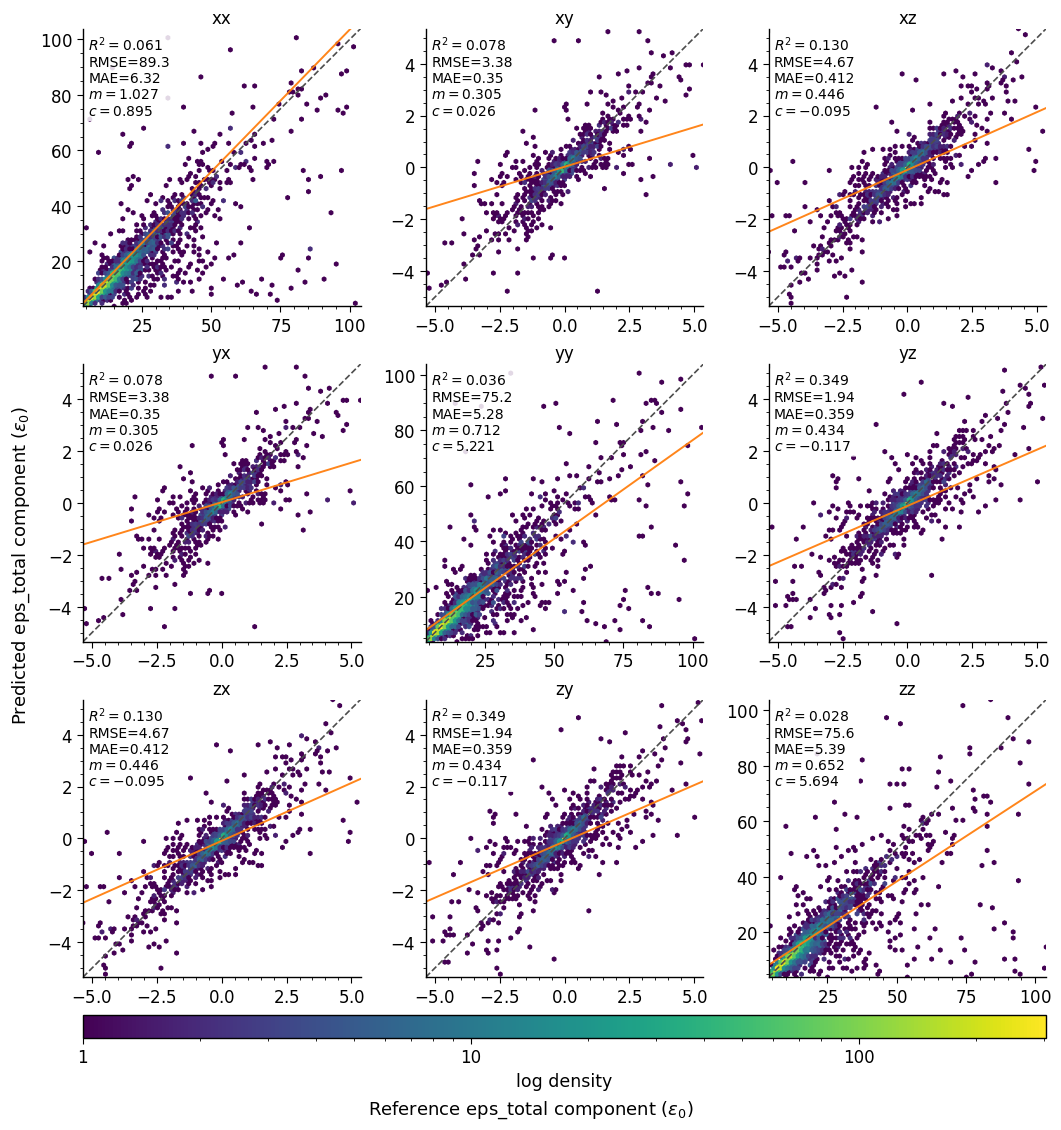

In [211]:
fig, axs = plot_polarisability_parity(ref_ionic+ref_electronic, mace_ionic+mace_electronic, units=fr"$\epsilon_0$", gridsize=80, annotate='long', pct_limits_diag=(1, 99), pct_limits_offd=(1, 99))
fig.savefig("eps_total_parity_hex_all-mh.png", bbox_inches="tight")

In [175]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator, ScalarFormatter, LogFormatter
import itertools

def _two_panel_parity_hex(
    REF, PRED, *, units="", diag_nonneg=False,
    pct_limits_diag=(.1, 99.9), pct_limits_offd=(.1, 99.9),
    gridsize=55, cmap="viridis", annotate="short",
    figsize=(9.5, 3.9), lw_guide=1.1, lw_fit=1.3
):
    """
    REF, PRED: arrays of shape (N, 3, 3). Returns (fig, (ax_diag, ax_offd)).
    """
    REF = np.asarray(REF); PRED = np.asarray(PRED)
    assert REF.shape == PRED.shape and REF.shape[1:] == (3, 3)

    # Collect data
    x_diag = np.concatenate([REF[:, k, k] for k in range(3)])
    y_diag = np.concatenate([PRED[:, k, k] for k in range(3)])
    off_pairs = [(i, j) for i in range(3) for j in range(3) if i != j]
    x_offd = np.concatenate([REF[:, i, j] for (i, j) in off_pairs])
    y_offd = np.concatenate([PRED[:, i, j] for (i, j) in off_pairs])

    def clean(x, y):
        m = np.isfinite(x) & np.isfinite(y)
        return x[m], y[m]

    x_diag, y_diag = clean(x_diag, y_diag)
    x_offd, y_offd = clean(x_offd, y_offd)

    # Limits
    def sym_lim(x, y, p=(1, 99), pad=1.05):
        v = np.r_[x, y]
        ql, qh = np.percentile(v, p)
        L = max(abs(ql), abs(qh))
        return (-pad*L if L > 0 else -1.0, pad*L if L > 0 else 1.0)

    def diag_lim(x, y, p=(1, 99), pad=1.05, nonneg=False):
        v = np.r_[x, y]
        ql, qh = np.percentile(v, p)
        if nonneg:
            upper = max(qh, 0.0)
            U = pad*upper if upper > 0 else 1.0
            return (0.0, U)
        else:
            return sym_lim(x, y, p, pad)

    lim_diag = diag_lim(x_diag, y_diag, pct_limits_diag, nonneg=diag_nonneg)
    lim_offd = sym_lim(x_offd, y_offd, pct_limits_offd)

    def fit_stats(x, y):
        m, c = np.polyfit(x, y, 1)
        yhat = m*x + c
        resid = y - yhat
        rmse = float(np.sqrt(np.mean(resid**2)))
        mae  = float(np.mean(np.abs(y - x)))
        ss_res = float(np.sum(resid**2))
        ss_tot = float(np.sum((y - np.mean(y))**2))
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        return m, c, r2, rmse, mae

    # Figure (two columns + slim colorbar on the right)
    fig, (axD, axO) = plt.subplots(1, 2, figsize=figsize, constrained_layout=False)
    plt.subplots_adjust(left=0.08, right=0.88, bottom=0.18, top=0.90, wspace=0.35)

    # Plot helper
    def panel(ax, x, y, lim, title):
        hb = ax.hexbin(x, y, gridsize=gridsize, extent=(*lim, *lim),
                       bins='log', cmap=cmap, mincnt=1, rasterized=True)
        ax.plot(lim, lim, '--', color='0.35', lw=lw_guide, zorder=1)
        if x.size >= 2:
            m, c, r2, rmse, mae = fit_stats(x, y)
            xx = np.linspace(*lim, 2)
            ax.plot(xx, m*xx + c, color='tab:orange', lw=lw_fit, alpha=0.95)
            if annotate and annotate.lower() != "none":
                if annotate == "short":
                    txt = (fr"$R^2={r2:.3f}$" "\n"
                           fr"RMSE={rmse:.3g}" "\n"
                           fr"MAE={mae:.3g}")
                else:  # "long"
                    txt = (fr"$R^2={r2:.3f}$" "\n"
                           fr"RMSE={rmse:.3g}" "\n"
                           fr"MAE={mae:.3g}" "\n"
                           fr"$m={m:.3f},\ c={c:.3f}$")
                ax.text(0.02, 0.98, txt, transform=ax.transAxes,
                        ha='left', va='top', fontsize=10,
                        bbox=dict(facecolor='white', alpha=0.85, edgecolor='none',
                                  boxstyle='round,pad=0.25'))
        ax.set_title(title, pad=3)
        ax.set_xlim(*lim); ax.set_ylim(*lim)
        ax.set_aspect('equal', adjustable='box')
        for s in ("top", "right"): ax.spines[s].set_visible(False)
        ax.xaxis.set_minor_locator(AutoMinorLocator()); ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.tick_params(which='minor', length=2)
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        return hb

    mappable = panel(axD, x_diag, y_diag, lim_diag, "diagonals (xx, yy, zz)")
    panel(axO, x_offd, y_offd, lim_offd, "off-diagonals (xy, xz, yx, yz, zx, zy)")

    # Shared labels + slim vertical colorbar
    u = f" ({units})" if units else ""
    fig.supxlabel(f"REF electronic dielectric{u}", fontsize=12.5)
    fig.supylabel(f"MACE electronic dielectric{u}", fontsize=12.5)

    cax = fig.add_axes([0.90, 0.22, 0.015, 0.60])
    cb = fig.colorbar(mappable, cax=cax, orientation='vertical')
    cb.set_label("log density", fontsize=10)
    cb.formatter = LogFormatter(10, labelOnlyBase=False); cb.update_ticks()

    return fig, (axD, axO)

In [212]:
def plot_ionic_parity_2panel(REF_ionic, PRED_ionic, **kwargs):
    return _two_panel_parity_hex(
        REF_ionic, PRED_ionic,
        units="ϵ0",
        diag_nonneg=True,                 # α_ii ≥ 0
        **kwargs
    )

In [198]:
diff = np.abs(ref_electronic - mace_electronic)   # shape: (N, 3, 3)

bad = np.any(diff > 15, axis=(1, 2))               # shape: (N,)
keep = ~bad

ref_electronic = ref_electronic[keep]
mace_electronic = mace_electronic[keep]

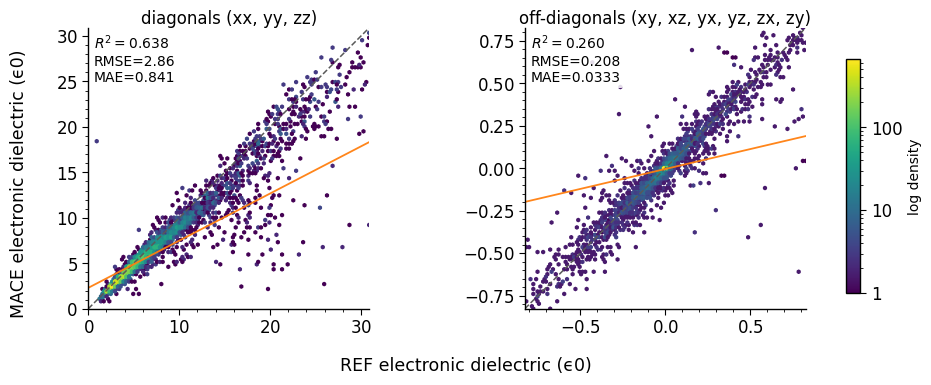

In [213]:
fig, axs = plot_ionic_parity_2panel(ref_electronic, mace_electronic, gridsize=100, annotate="short", pct_limits_diag=(1, 99), pct_limits_offd=(1, 99))
fig.savefig("MACEField-eps_electronic_parity-omat.png", bbox_inches="tight")

In [207]:
from ase.io import read
import numpy as np

dielectric = read("analysis_outputs/foundation_workflow/parity/predictions/dielectric_filtered_test__MACEField-omat-dielectric.extxyz", ":") + read("analysis_outputs/foundation_workflow/parity/predictions/dielectric_filtered_valid__MACEField-omat-dielectric.extxyz", ":") + read("analysis_outputs/foundation_workflow/parity/predictions/dielectric_filtered_train__MACEField-omat-dielectric.extxyz", ":")

In [ ]:
eps_0 = 8.8541878128e-12 / 1.602176634e-19 / 1e10
eps_0

0.00552634935805711

In [95]:
chi_ref = np.asarray([x.info["REF_polarizability"] for x in dielectric]).reshape(-1,3,3)
chi_mace = np.asarray([x.info["MACE_polarizability"] for x in dielectric]).reshape(-1,3,3)
Z_ref = np.concatenate([np.asarray(x.arrays["REF_becs"]).reshape(-1,3,3) for x in dielectric])
Z_mace = np.concatenate([np.asarray(x.arrays["MACE_becs"]).reshape(-1,3,3) for x in dielectric])

In [96]:
from ase.io import read
import numpy as np
mp_replay = read("analysis_outputs/foundation_workflow/parity/predictions/replay_mh0_omat_pbe__MACEField-omat-dielectric.extxyz", ":")
mp_replay_becs = np.concatenate([np.asarray(atom.arrays['MACE_becs']).reshape(-1,3,3) for atom in mp_replay]).reshape(-1,3,3)
mp_replay_chis = np.asarray([x.info["MACE_polarizability"] for x in mp_replay]).reshape(-1,3,3)

In [234]:
import numpy as np
import matplotlib.pyplot as plt

from itertools import cycle, islice
from scipy.stats import gaussian_kde
from matplotlib.ticker import AutoMinorLocator, MaxNLocator


def plot_matrix_component_density(
    datasets,
    component="diag",   # "diag" or "off"
    labels=None,
    use_hist=False,
    bins=70,
    linewidth=3.0,
    title=None,
    xlabel=r"$Z^\ast$ value (e)",
    ylabel="Probability density",
    figsize=(4.2, 3.2),
    legend_loc="upper right",
    colors=None,
    linestyles=None,
    percentiles=(0.5, 99.5),
    bw_method="scott",
    output=None,
    dpi=300,
    return_ax=False,
):
    """
    Plot a single publication-style density plot for either diagonal
    or off-diagonal components of 3x3 matrix datasets.

    Parameters
    ----------
    datasets : list of arrays
        Each array must have shape (N, 3, 3).
    component : str
        Either "diag" or "off".
    """

    if component not in {"diag", "off"}:
        raise ValueError("component must be either 'diag' or 'off'.")

    if not isinstance(datasets, (list, tuple)) or len(datasets) == 0:
        raise ValueError("datasets must be a non-empty sequence of arrays with shape (N, 3, 3).")

    clean_datasets = []
    for k, arr in enumerate(datasets):
        arr = np.asarray(arr, dtype=float)
        if arr.ndim != 3 or arr.shape[1:] != (3, 3):
            raise ValueError(f"datasets[{k}] must have shape (N, 3, 3)")
        clean_datasets.append(arr)
    datasets = clean_datasets

    n_sets = len(datasets)

    if labels is None:
        labels = [f"Set {i+1}" for i in range(n_sets)]
    elif len(labels) != n_sets:
        raise ValueError("labels must have the same length as datasets.")

    # Okabe-Ito color-blind-safe palette
    if colors is None:
        base_colors = [
            "#0072B2",  # blue
            "#D55E00",  # vermillion
            "#009E73",  # green
            "#CC79A7",  # purple
            "#E69F00",  # orange
            "#56B4E9",  # sky blue
            "#000000",  # black
        ]
        colors = list(islice(cycle(base_colors), n_sets))
    else:
        colors = list(islice(cycle(colors), n_sets))

    if linestyles is None:
        linestyles = list(islice(cycle(["-", "--", "-.", ":"]), n_sets))
    else:
        linestyles = list(islice(cycle(linestyles), n_sets))

    def pool_components(arr, diagonal=True):
        if diagonal:
            values = np.diagonal(arr, axis1=1, axis2=2).ravel()
        else:
            mask = ~np.eye(3, dtype=bool)
            values = arr[:, mask].ravel()
        return values[np.isfinite(values)]

    pooled = [
        pool_components(arr, diagonal=(component == "diag"))
        for arr in datasets
    ]

    all_vals = [v for v in pooled if v.size > 0]
    if len(all_vals) == 0:
        raise ValueError("No finite values found to plot.")

    all_vals = np.concatenate(all_vals)

    lo, hi = np.percentile(all_vals, percentiles)
    if not np.isfinite(lo) or not np.isfinite(hi) or np.isclose(lo, hi):
        lo, hi = np.nanmin(all_vals), np.nanmax(all_vals)

    if np.isclose(lo, hi):
        pad = 0.5 if np.isclose(lo, 0.0) else 0.1 * abs(lo)
    else:
        pad = 0.04 * (hi - lo)

    xlim = (lo - pad, hi + pad)
    xs = np.linspace(*xlim, 500)

    rc = {
        "font.size": 15,
        "axes.labelsize": 15,
        "axes.titlesize": 15,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 10,
        "legend.frameon": False,
        "axes.linewidth": 1.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "mathtext.default": "regular",
    }

    with plt.rc_context(rc):
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

        ymax = 0.0

        for i, values in enumerate(pooled):
            if values.size == 0:
                continue

            if use_hist:
                density, _, _ = ax.hist(
                    values,
                    bins=bins,
                    density=True,
                    histtype="step",
                    linewidth=linewidth,
                    linestyle=linestyles[i],
                    color=colors[i],
                    label=labels[i],
                )
                ymax = max(ymax, float(np.nanmax(density)))
            else:
                try:
                    if values.size < 3 or np.nanstd(values) == 0:
                        raise ValueError("Insufficient variation for KDE.")

                    kde = gaussian_kde(values, bw_method=bw_method)
                    density = kde(xs)

                    ax.plot(
                        xs,
                        density,
                        linewidth=linewidth,
                        linestyle=linestyles[i],
                        color=colors[i],
                        label=labels[i],
                    )
                    ymax = max(ymax, float(np.nanmax(density)))

                except Exception:
                    density, _, _ = ax.hist(
                        values,
                        bins=bins,
                        density=True,
                        histtype="step",
                        linewidth=linewidth,
                        linestyle=linestyles[i],
                        color=colors[i],
                        label=labels[i],
                    )
                    ymax = max(ymax, float(np.nanmax(density)))

        ax.axvline(0.0, linestyle=":", linewidth=1.0, color="0.35", zorder=0)

        ax.set_xlim(xlim)
        if ymax > 0:
            ax.set_ylim(0.0, 1.08 * ymax)

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        if title is not None:
            ax.set_title(title, pad=6)

        ax.tick_params(axis="both", which="major", direction="in", length=4.0, width=0.8)
        ax.tick_params(axis="both", which="minor", direction="in", length=2.2, width=0.6)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.0)
        ax.spines["bottom"].set_linewidth(1.0)

        handles, legend_labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles, legend_labels, loc=legend_loc, handlelength=2.6)

        if output is not None:
            fig.savefig(output, dpi=dpi, bbox_inches="tight")

        if not return_ax:
            plt.show()

    return fig, ax


def plot_diag_offdiag_separate(
    datasets,
    labels=None,
    use_hist=False,
    diag_title="Diagonal components",
    offdiag_title="Off-diagonal components",
    diag_output=None,
    offdiag_output=None,
):
    """
    Convenience wrapper: make separate figures for diagonal and off-diagonal components.
    """

    fig1, ax1 = plot_matrix_component_density(
        datasets=datasets,
        labels=labels,
        component="diag",
        use_hist=use_hist,
        title=diag_title,
        figsize=(5.0, 5.0),
        output=diag_output,
        return_ax=True,
    )

    fig2, ax2 = plot_matrix_component_density(
        datasets=datasets,
        labels=labels,
        component="off",
        use_hist=use_hist,
        title=offdiag_title,
        figsize=(5.0, 5.0),
        output=offdiag_output,
        return_ax=True,
    )

    plt.show()
    return (fig1, ax1), (fig2, ax2)

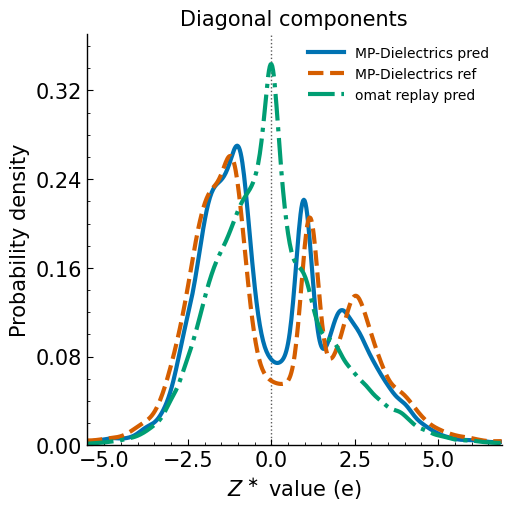

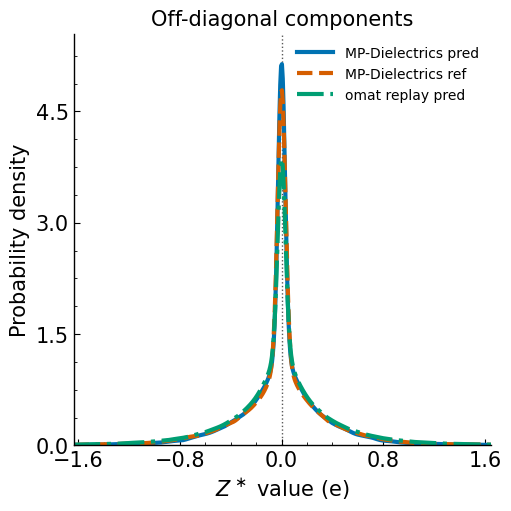

In [235]:
(fig_diag, ax_diag), (fig_off, ax_off) = plot_diag_offdiag_separate(
    datasets=[Z_mace, Z_ref, mp_replay_becs],
    labels=["MP-Dielectrics pred", "MP-Dielectrics ref", "omat replay pred"],
    use_hist=False,
    diag_title="Diagonal components",
    offdiag_title="Off-diagonal components",
    diag_output="bec_diag_density.png",
    offdiag_output="bec_offdiag_density.png",
)

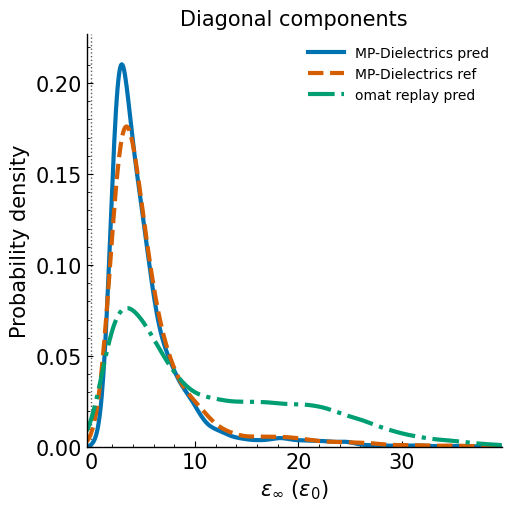

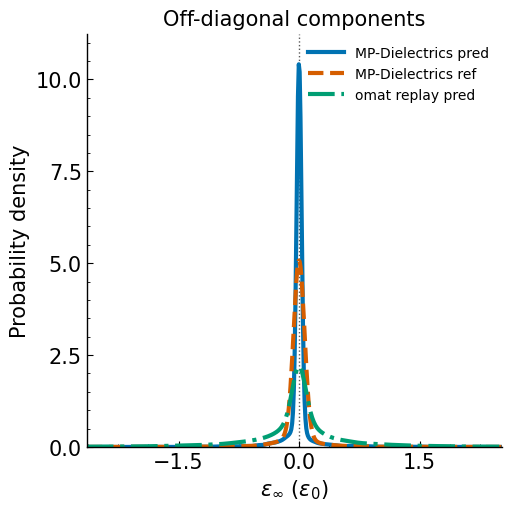

In [237]:
fig_diag, ax_diag = plot_matrix_component_density(
    datasets=[
        chi_mace + np.eye(3),
        chi_ref + np.eye(3),
        mp_replay_chis + np.eye(3),
    ],
    labels=[
        "MP-Dielectrics pred",
        "MP-Dielectrics ref",
        "omat replay pred",
    ],
    component="diag",
    title="Diagonal components",
    xlabel=r"$\epsilon_{\infty}$ ($\varepsilon_0$)",
    ylabel="Probability density",
    figsize=(5.0, 5.0),
    output="eps_inf_diag_density.png",
    return_ax=True,
)

fig_off, ax_off = plot_matrix_component_density(
    datasets=[
        chi_mace + np.eye(3),
        chi_ref + np.eye(3),
        mp_replay_chis + np.eye(3),
    ],
    labels=[
        "MP-Dielectrics pred",
        "MP-Dielectrics ref",
        "omat replay pred",
    ],
    component="off",
    title="Off-diagonal components",
    xlabel=r"$\epsilon_{\infty}$ ($\varepsilon_0$)",
    ylabel="Probability density",
    figsize=(5.0, 5.0),
    output="eps_inf_offdiag_density.png",
    return_ax=True,
)

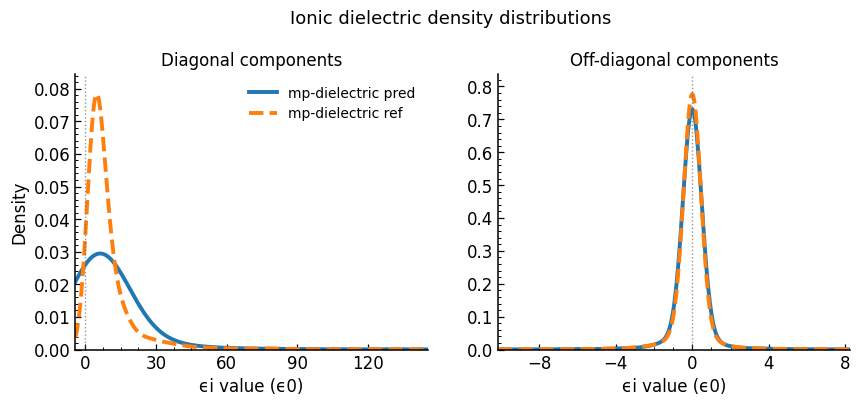

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Diagonal components'}, xlabel='ϵi value (ϵ0)', ylabel='Density'>,
        <Axes: title={'center': 'Off-diagonal components'}, xlabel='ϵi value (ϵ0)'>],
       dtype=object))

In [100]:
plot_matrix_component_densities(
    datasets=[mace_ionic, ref_ionic],
    labels=["mp-dielectric pred", "mp-dielectric ref"],
    use_hist=False,                   # KDE
    title="Ionic dielectric density distributions",
    xlabel="ϵi value (ϵ0)",
    ylabel="Density",
)